In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("IT_Support_Ticket_Dataset_Cleaned.csv")

print(df.head(1))

   Ticket_ID         Created_Date      Resolution_Date    Status Priority  \
0  TCK-00001  2025-05-30 20:01:00  2025-06-05 08:01:05  Resolved   Medium   

  Ticket_Type Category Country Region  Latitude  ...     Product  \
0      Change  Network   India   APAC   21.0833  ...  VPN Client   

   Customer_Satisfaction Escalation_Level  Device_Type Operating_System  \
0                    NaN                0      Desktop          Windows   

                         Resolution_Notes Resolution_Duration Priority_Score  \
0  Issue resolved via workaround applied.                 5.0              2   

  First_Response_Time         Queue  
0           19.520278  Service Desk  

[1 rows x 36 columns]


In [ ]:
print(df.columns.tolist())

['Ticket_ID', 'Created_Date', 'Resolution_Date', 'Status', 'Priority', 'Ticket_Type', 'Category', 'Country', 'Region', 'Latitude', 'Longitude', 'Cluster_ID', 'Cluster_Name', 'Similarity_Score', 'Similarity_Level', 'First_Response_Date', 'Assigned_Agent', 'Team', 'SLA_Status', 'Reopened', 'Resolution_Code', 'Department', 'Customer_ID', 'Channel', 'Description', 'Tags', 'Product', 'Customer_Satisfaction', 'Escalation_Level', 'Device_Type', 'Operating_System', 'Resolution_Notes', 'Resolution_Duration', 'Priority_Score', 'First_Response_Time', 'Queue']


In [ ]:
region_counts = df["Region"].value_counts().reset_index()
region_counts.columns = ["Region", "Ticket_Count"]

print(region_counts)

  Region  Ticket_Count
0   APAC          5389
1   AMER          3462
2   EMEA          3149


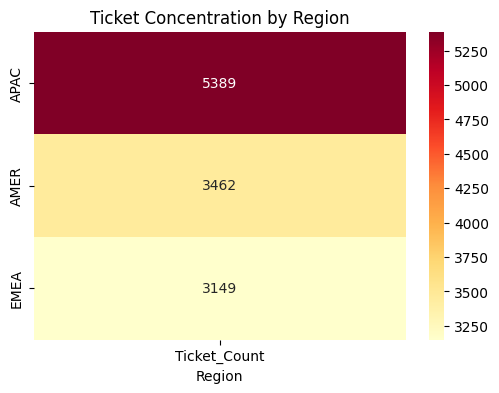

In [ ]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    region_counts.set_index("Region"),
    annot=True,
    fmt="g",
    cmap="YlOrRd"
)

plt.title("Ticket Concentration by Region")
plt.xlabel("Region")
plt.ylabel("")

plt.show()



In [ ]:
!pip install plotly

In [ ]:
import plotly.express as px

fig = px.scatter_geo(
    df,
    lat="Latitude",
    lon="Longitude",
    color="Category",
    hover_name="Ticket_ID",
    hover_data=[
        "Category",
        "Country",
        "Region",
        "Priority",
        "Status"
    ],
    title="Global Distribution of IT Support Issue Categories"
)

fig.update_geos(
    showcountries=True,
    showcoastlines=True,
    showland=True,
    showocean=True,
    projection_type="natural earth"
)

fig.update_layout(
    height=650,
    legend_title="Issue Category"
)

fig.show()

In [ ]:
cluster_analysis = (
    df.groupby("Cluster_Name")
      .agg(
          Cluster_Size=("Cluster_Name", "count"),
          Average_Similarity_Score=("Similarity_Score", "mean")
      )
      .reset_index()
)

print(cluster_analysis)

                      Cluster_Name  Cluster_Size  Average_Similarity_Score
0           API Integration Errors           930                  0.641297
1       Application Crashes / Bugs          1263                  0.700068
2   Data Sync / Integration Delays           739                  0.847463
3          Database Query Failures           730                  0.789226
4            Hardware Malfunctions           557                  0.733747
5          Login & Access Failures          1354                  0.574835
6      Network Connectivity Issues          1197                  0.607691
7          Patch & Update Failures           386                  0.962391
8          Performance Degradation           973                  0.758434
9         Permission / Role Errors           605                  0.949990
10        Security Vulnerabilities           734                  0.670955
11                 Server Downtime           458                  0.929836
12             Slow Respo

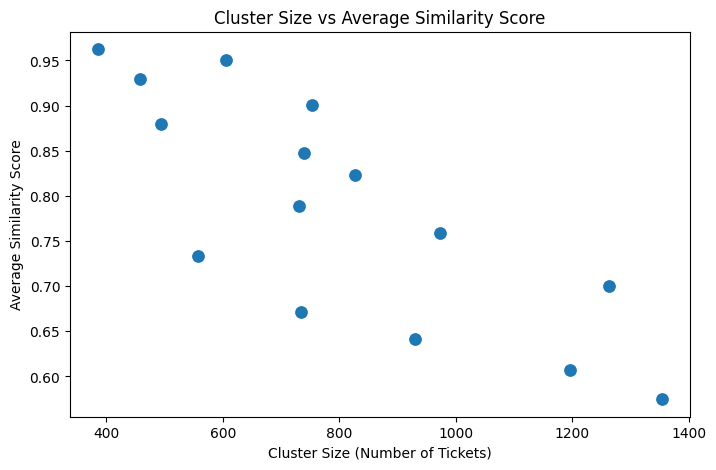

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=cluster_analysis,
    x="Cluster_Size",
    y="Average_Similarity_Score",
    s=100
)

plt.title("Cluster Size vs Average Similarity Score")
plt.xlabel("Cluster Size (Number of Tickets)")
plt.ylabel("Average Similarity Score")

plt.show()

In [ ]:
performance_summary = pd.DataFrame({
    "Metric": [
        "Total Tickets",
        "Total Regions",
        "Total Issue Categories",
        "Total Clusters",
        "Average Resolution Duration",
        "Average Similarity Score"
    ],
    "Value": [
        len(df),
        df["Region"].nunique(),
        df["Category"].nunique(),
        df["Cluster_Name"].nunique(),
        round(df["Resolution_Duration"].mean(), 2),
        round(df["Similarity_Score"].mean(), 2)
    ]
})

print(performance_summary)

                        Metric     Value
0                Total Tickets  12000.00
1                Total Regions      3.00
2       Total Issue Categories      9.00
3               Total Clusters     15.00
4  Average Resolution Duration      3.70
5     Average Similarity Score      0.75
